# compare cinv

In [1]:
from astropy.table import Table, vstack, hstack
import numpy as np
import numpy.ma as ma
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib as mpl

from IPython.display import Image

from color_gradient_functions import pogson_mag_from_flux, extract_cog_data, SGA_cog

from scipy.optimize import curve_fit, minimize

## load tables

In [2]:
DATA_FOLDER = '/pscratch/sd/n/nravi/GV_classification/'

In [3]:
kias = Table.read(DATA_FOLDER + 'NSA_v1_0_1_vflag_Portsmouth.fits')

In [4]:
kias[:5]

IAUNAME,SUBDIR,RA,DEC,ISDSS,INED,ISIXDF,IALFALFA,IZCAT,ITWODF,MAG,Z,ZSRC,SIZE,RUN,CAMCOL,FIELD,RERUN,XPOS,YPOS,NSAID,ZDIST,SERSIC_NMGY,SERSIC_NMGY_IVAR,SERSIC_OK,SERSIC_RNMGY,SERSIC_ABSMAG,SERSIC_AMIVAR,EXTINCTION,SERSIC_KCORRECT,SERSIC_KCOEFF,SERSIC_MTOL,SERSIC_B300,SERSIC_B1000,SERSIC_METS,SERSIC_MASS,XCEN,YCEN,NPROF,PROFMEAN,PROFMEAN_IVAR,QSTOKES,USTOKES,BASTOKES,PHISTOKES,PETRO_FLUX,PETRO_FLUX_IVAR,FIBER_FLUX,FIBER_FLUX_IVAR,PETRO_BA50,PETRO_PHI50,PETRO_BA90,PETRO_PHI90,SERSIC_FLUX,SERSIC_FLUX_IVAR,SERSIC_N,SERSIC_BA,SERSIC_PHI,ASYMMETRY,CLUMPY,DFLAGS,AID,PID,DVERSION,PROFTHETA,PETRO_THETA,PETRO_TH50,PETRO_TH90,SERSIC_TH50,PLATE,FIBERID,MJD,RACAT,DECCAT,ZSDSSLINE,SURVEY,PROGRAMNAME,PLATEQUALITY,TILE,PLUG_RA,PLUG_DEC,ELPETRO_BA,ELPETRO_PHI,ELPETRO_FLUX_R,ELPETRO_FLUX_IVAR_R,ELPETRO_THETA_R,ELPETRO_TH50_R,ELPETRO_TH90_R,ELPETRO_THETA,ELPETRO_FLUX,ELPETRO_FLUX_IVAR,ELPETRO_TH50,ELPETRO_TH90,ELPETRO_APCORR_R,ELPETRO_APCORR,ELPETRO_APCORR_SELF,ELPETRO_NMGY,ELPETRO_NMGY_IVAR,ELPETRO_OK,ELPETRO_RNMGY,ELPETRO_ABSMAG,ELPETRO_AMIVAR,ELPETRO_KCORRECT,ELPETRO_KCOEFF,ELPETRO_MASS,ELPETRO_MTOL,ELPETRO_B300,ELPETRO_B1000,ELPETRO_METS,IN_DR7_LSS,u_r,g_r,NUV_r,index,imc,aimc,cd,conx1,u_r_KIAS,prmag,BPTclass,SFR,sSFR,HImass,vflag,u_r_err,g_r_err,NUV_r_err,ID,Flux_OII_3726,Flux_OII_3726_Err,AoN_OII_3726,Flux_OII_3728,Flux_OII_3728_Err,AoN_OII_3728,Flux_OIII_4363,Flux_OIII_4363_Err,AoN_OIII_4363,Flux_Hb_4861,Flux_Hb_4861_Err,AoN_Hb_4861,Flux_OIII_4958,Flux_OIII_4958_Err,Flux_OIII_5006,Flux_OIII_5006_Err,AoN_OIII_5006,Flux_NI_5197,Flux_NI_5197_Err,AoN_NI_5197,Flux_NI_5200,Flux_NI_5200_Err,AoN_NI_5200,Flux_OI_6300,Flux_OI_6300_Err,AoN_OI_6300,Flux_OI_6363,Flux_OI_6363_Err,AoN_OI_6363,Flux_NII_6547,Flux_NII_6547_Err,Flux_Ha_6562,Flux_Ha_6562_Err,AoN_Ha_6562,Flux_NII_6583,Flux_NII_6583_Err,AoN_NII_6583,Flux_SII_6716,Flux_SII_6716_Err,AoN_SII_6716,Flux_SII_6730,Flux_SII_6730_Err,AoN_SII_6730
bytes19,bytes27,float64,float64,int32,int32,int32,int32,int32,int32,float32,float32,bytes7,float32,int16,uint8,int16,bytes3,float32,float32,int32,float32,float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[7],float32[5],float32[7],float32,float32,float32,float32,float64,float64,uint8[7],"float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]",float32[7],float32[7],float32[7],float32[7],float32,float32,float32,float32,float32[7],float32[7],float32,float32,float32,float32[7],float32[7],int32[7],int32,int32,bytes8,float32[15],float32,float32,float32,float32,int32,int16,int32,float64,float64,float32,bytes6,bytes27,bytes8,int32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32[7],float32[7],float32[7],float32[7],float32,float32[7],float32[7],float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[5],float32,float32[7],float32,float32,float32,float64,float32,float32,float32,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
J023211.77+001326.5,02h/p00/J023211.77+001326.5,38.04906209256324,0.22402153989646575,39438,22721,-1,-1,71327,-1,16.771198,0.054021582,sdss,0.07,109,4,23,301,1960.5631,83.361275,38979,0.054392263,1.3420134 .. 884.58374,16.215242 .. 0.0016165179,1,1.4780203 .. 964.8986,-13.908231 .. -21.045618,24.77356 .. 1073.0248,0.2271526 .. 0.04052578,-0.060923357 .. 0.029009609,1.4557369e-05 .. 1.222673e-15,0.0016189957 .. 1.23927,2.5023096e-06,0.06656253,0.024689334,22540354000.0,156.48558044433594,201.36697387695312,10 .. 11,0.016490662 .. 0.0,5489.7393 .. 0.0,0.21582535 .. -0.09177922,0.0076095443 .. 0.15974313,0.64479166 ..

In [5]:
nsa = Table.read(DATA_FOLDER + 'nsa_v1_0_1_cd_v3_cinv.fits')

In [6]:
nsa_dict = {}
for i in range(len(nsa)):

    nsa_dict[nsa['IAUNAME'][i]] = i

In [7]:
nsa['kias_cinv'] = np.ones(len(nsa))**np.nan

In [8]:
for i in tqdm(range(len(kias))):

    iauname = kias['IAUNAME'][i]
    i_nsa = nsa_dict[iauname]

    nsa['kias_cinv'][i_nsa] = kias['conx1'][i]

100%|██████████| 641409/641409 [00:03<00:00, 184568.35it/s]


## plots

Text(0, 0.5, 'KIAS cinv')

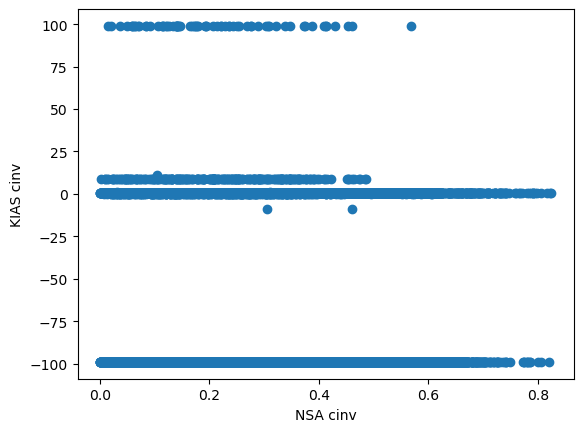

In [9]:
plt.scatter(nsa['cinv'], nsa['kias_cinv'])
plt.xlabel('NSA cinv')
plt.ylabel('KIAS cinv')

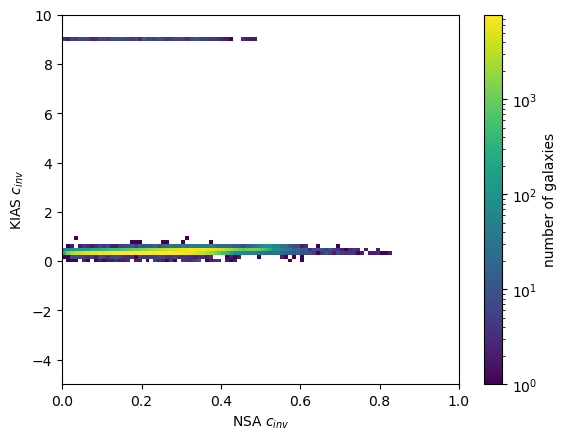

In [10]:
plt.hist2d(nsa['cinv'], nsa['kias_cinv'], 
          # alpha=0.1, marker='.', 
           bins=100, 
           range=[[0, 1], [-5, 10]], 
           norm=mpl.colors.LogNorm())
plt.xlabel(r'NSA $c_{inv}$')
plt.ylabel(r'KIAS $c_{inv}$')
# plt.plot([-1,1],[-1,1], color='r', linewidth=2)
plt.colorbar(label='number of galaxies')

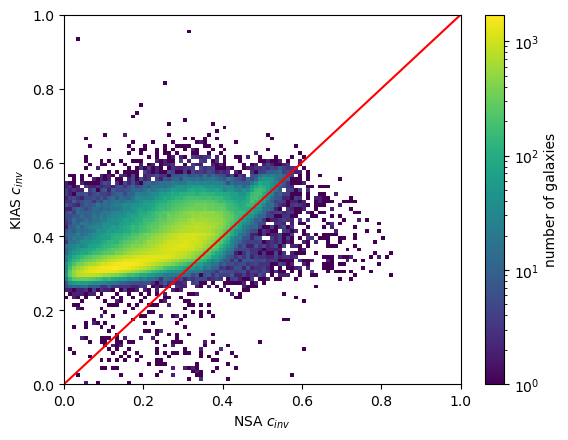

In [11]:
plt.hist2d(nsa['cinv'], nsa['kias_cinv'], 
          # alpha=0.1, marker='.', 
           bins=100, 
           range=[[0, 1], [0, 1]], 
           norm=mpl.colors.LogNorm())
plt.xlabel(r'NSA $c_{inv}$')
plt.ylabel(r'KIAS $c_{inv}$')
# plt.plot([-1,1],[-1,1], color='r', linewidth=2)
plt.colorbar(label='number of galaxies')
plt.plot([0,1],[0,1], color='r')

In [12]:
nsa[nsa['cinv'] < 0.01][:5]

IAUNAME,SUBDIR,RA,DEC,ISDSS,INED,ISIXDF,IALFALFA,IZCAT,ITWODF,MAG,Z,ZSRC,SIZE,RUN,CAMCOL,FIELD,RERUN,XPOS,YPOS,NSAID,ZDIST,SERSIC_NMGY,SERSIC_NMGY_IVAR,SERSIC_OK,SERSIC_RNMGY,SERSIC_ABSMAG,SERSIC_AMIVAR,EXTINCTION,SERSIC_KCORRECT,SERSIC_KCOEFF,SERSIC_MTOL,SERSIC_B300,SERSIC_B1000,SERSIC_METS,SERSIC_MASS,XCEN,YCEN,NPROF,PROFMEAN,PROFMEAN_IVAR,QSTOKES,USTOKES,BASTOKES,PHISTOKES,PETRO_FLUX,PETRO_FLUX_IVAR,FIBER_FLUX,FIBER_FLUX_IVAR,PETRO_BA50,PETRO_PHI50,PETRO_BA90,PETRO_PHI90,SERSIC_FLUX,SERSIC_FLUX_IVAR,SERSIC_N,SERSIC_BA,SERSIC_PHI,ASYMMETRY,CLUMPY,DFLAGS,AID,PID,DVERSION,PROFTHETA,PETRO_THETA,PETRO_TH50,PETRO_TH90,SERSIC_TH50,PLATE,FIBERID,MJD,RACAT,DECCAT,ZSDSSLINE,SURVEY,PROGRAMNAME,PLATEQUALITY,TILE,PLUG_RA,PLUG_DEC,ELPETRO_BA,ELPETRO_PHI,ELPETRO_FLUX_R,ELPETRO_FLUX_IVAR_R,ELPETRO_THETA_R,ELPETRO_TH50_R,ELPETRO_TH90_R,ELPETRO_THETA,ELPETRO_FLUX,ELPETRO_FLUX_IVAR,ELPETRO_TH50,ELPETRO_TH90,ELPETRO_APCORR_R,ELPETRO_APCORR,ELPETRO_APCORR_SELF,ELPETRO_NMGY,ELPETRO_NMGY_IVAR,ELPETRO_OK,ELPETRO_RNMGY,ELPETRO_ABSMAG,ELPETRO_AMIVAR,ELPETRO_KCORRECT,ELPETRO_KCOEFF,ELPETRO_MASS,ELPETRO_MTOL,ELPETRO_B300,ELPETRO_B1000,ELPETRO_METS,IN_DR7_LSS,g_mtot,g_m0,g_a1,g_a2,i_mtot,i_m0,i_a1,i_a2,NSA_cd,R50_i,R90_i,cinv,kias_cinv
bytes19,bytes27,float64,float64,int32,int32,int32,int32,int32,int32,float32,float32,bytes7,float32,int16,uint8,int16,bytes3,float32,float32,int32,float32,float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[7],float32[5],float32[7],float32,float32,float32,float32,float64,float64,uint8[7],"float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]",float32[7],float32[7],float32[7],float32[7],float32,float32,float32,float32,float32[7],float32[7],float32,float32,float32,float32[7],float32[7],int32[7],int32,int32,bytes8,float32[15],float32,float32,float32,float32,int32,int16,int32,float64,float64,float32,bytes6,bytes27,bytes8,int32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32[7],float32[7],float32[7],float32[7],float32,float32[7],float32[7],float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[5],float32,float32[7],float32,float32,float32,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
J094318.37+002223.1,09h/p00/J094318.37+002223.1,145.8265914536311,0.37311889540636867,240,71391,-1,-1,164867,-1,17.034388,0.021564012,sdss,0.07,756,4,200,301,1549.561,1183.397,240,0.02103973,16.503618 .. 484.36987,0.37890857 .. 0.001969591,1,13.073521 .. 471.417,-14.575186 .. -18.246435,87.54757 .. 391.99597,0.9077497 .. 0.16194956,-0.0029236758 .. -0.0006690348,3.6137697e-12 .. 2.5328416e-06,6.994418e-05 .. 1.0508285,0.023261672,0.023414578,0.020525774,1294609000.0,161.0711669921875,162.5813446044922,10 .. 11,0.040121745 .. 0.0,1642.4426 .. 0.0,-0.19447993 .. -0.17349304,0.002604686 .. -0.053860027,0.6743445 .. 0.69253266,89.61633 .. -81.376656,5.873729 .. 673.02124,0.7016972 .. 0.0005163705,0.09926276 .. 16.354092,349.90192 .. 0.46629262,0.78181696,41.736496,0.70667994,37.535614,7.1528525 .. 432.90967,2.34571 .. 0.0038097347,1.8427794,0.63918936,40.083008,-0.035108984 .. -0.6910236,0.044438362 .. -0.91614676,0 .. 0,0,42,v2_1_13,0.22341923 .. 258.39,23.6052,10.752045,28.096071,13.254214,266,435,51630,145.82654428119332,0.3731099474998585,0.0,sdss,legacy,good,122,145.82657,0.37310286,0.70667994,37.535614,261.59,0.0179383,27.945312,14.105606,41.81168,27.945312,5.2899704 .. 399.0448,0.70028037 .. 0.00047054017,9.708357 .. 13.070279,18.07577 .. 29.85363,1.0000104,1.0057116 .. 1.0000131,1.0088118 .. 0.99954003,12.205432 .. 446.4795,0.12813616 .. 0.0003555313,1,11.150368 .. 560.1069,-14.255531 .. -18.16336,16.193073 .. 60.121826,0.004987496 .. 0.004695384,9.0419035e-06 .. 2.8678182e-06,1478154100.0,9.295474e-05 .. 1.0048504,0.023510136,0.11460593,0.024841677,1.0,16.955474743951267,1.325429750922014,1.4584577561598757,1.4031612127612623,14.230458767203377,19

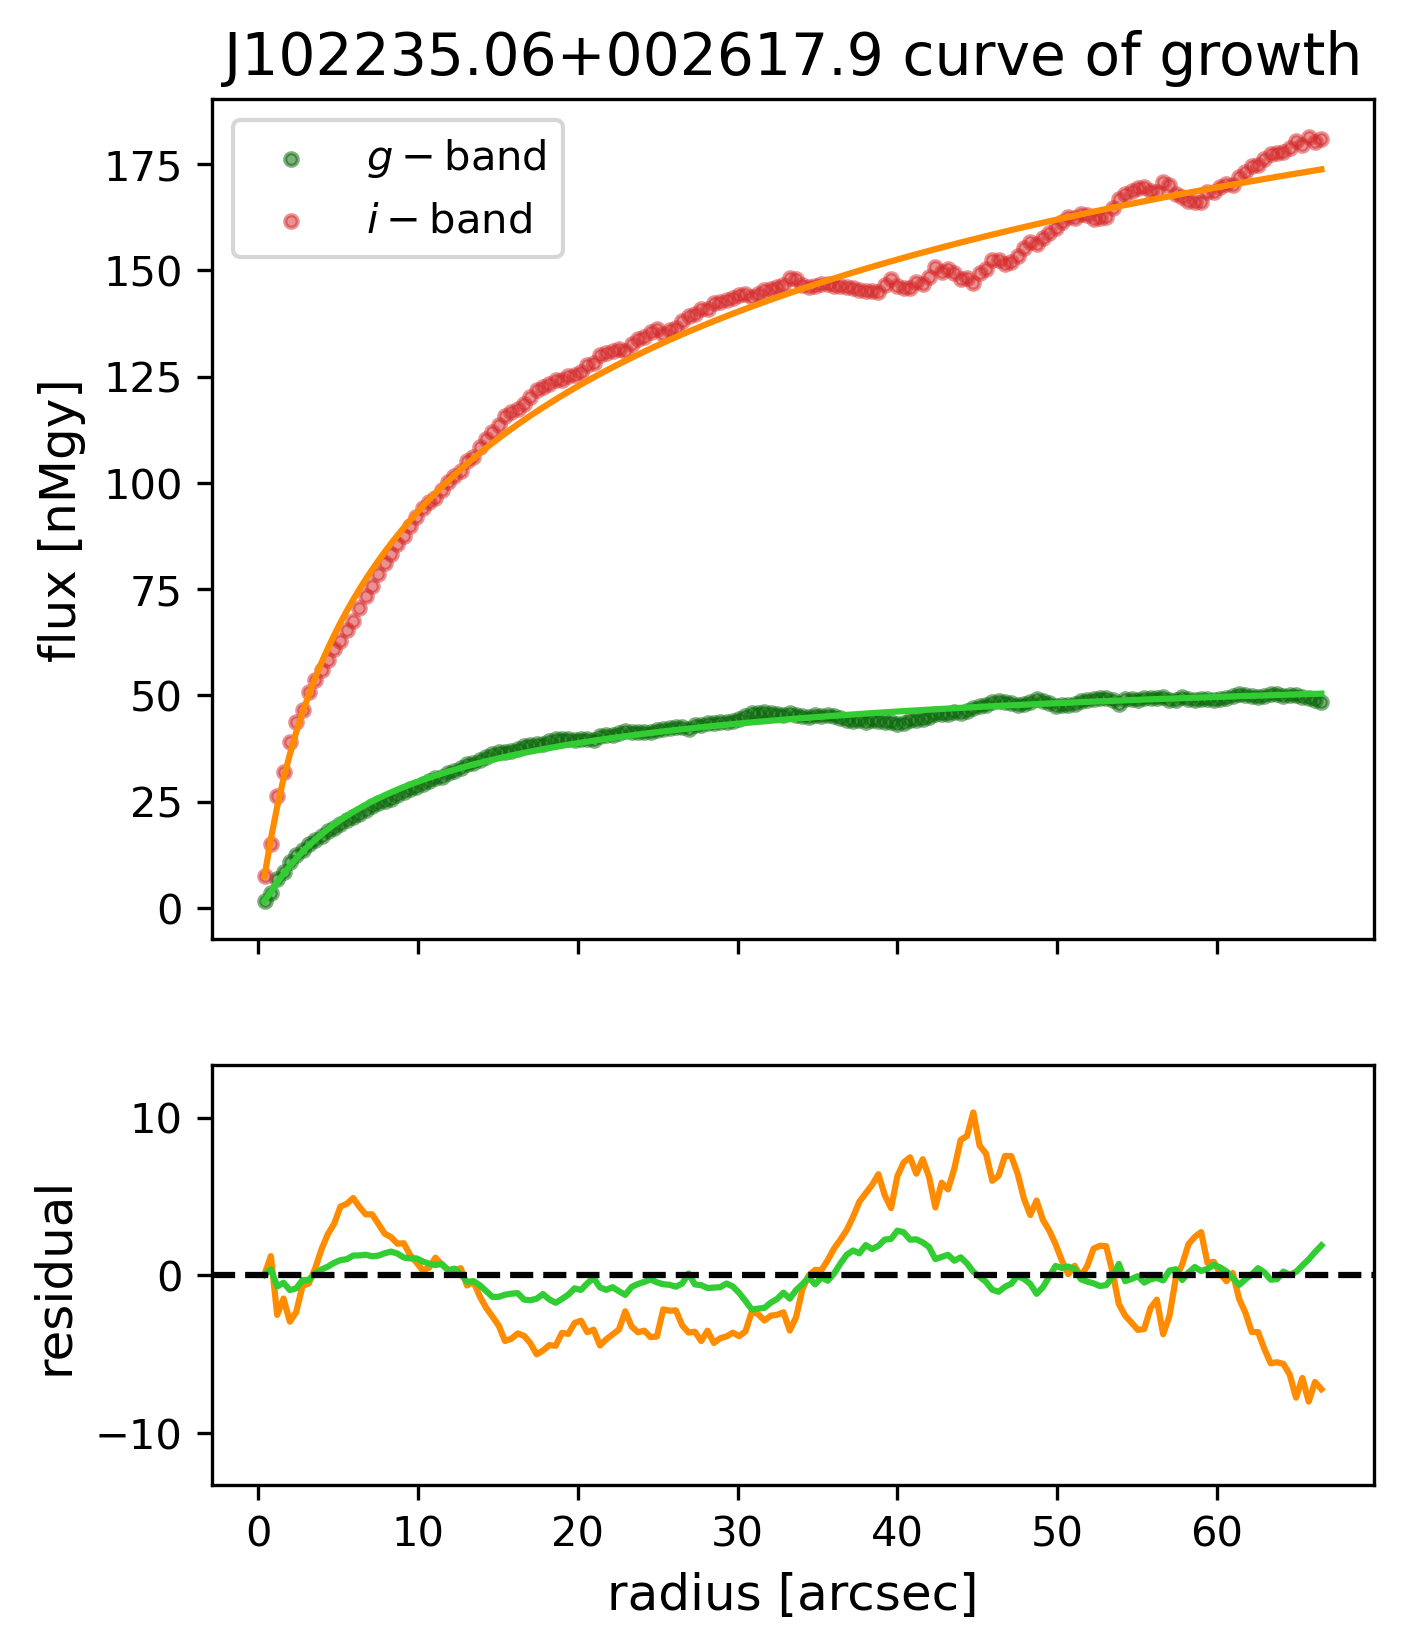

In [13]:
Image(DATA_FOLDER + '/cog_plots/' + 'J102235.06+002617.9' + '.png')

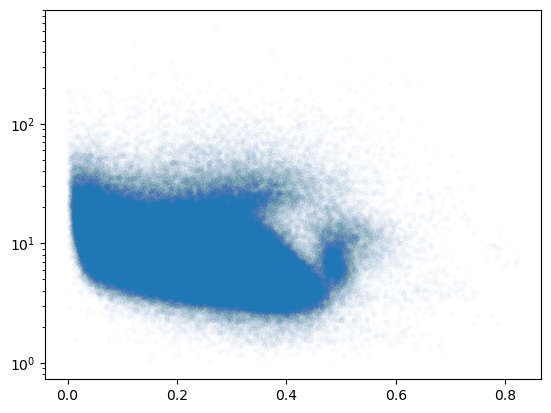

In [14]:
plt.scatter(nsa['cinv'], nsa['ELPETRO_TH90_R'], marker='.', alpha=0.01)
plt.yscale('log')

Text(0, 0.5, 'kias cinv')

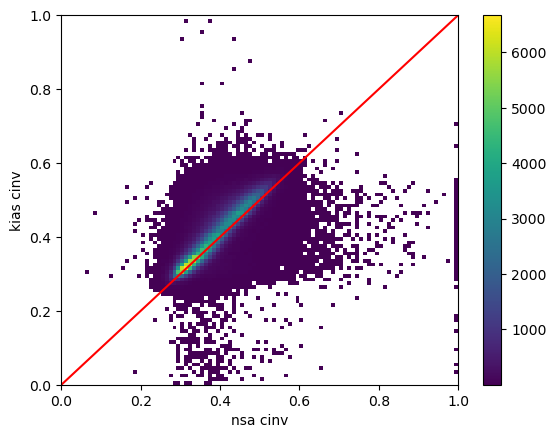

In [15]:
plt.hist2d(nsa['ELPETRO_TH50'][:,5]/nsa['ELPETRO_TH90'][:,5], nsa['kias_cinv'],
          bins=100,
          range=[[0,1],[0,1]],
          cmin=1)
plt.xlim(0,1)
plt.ylim(0,1)
plt.plot([0,1],[0,1], color='r')
plt.colorbar()
plt.xlabel('nsa cinv')
plt.ylabel('kias cinv')

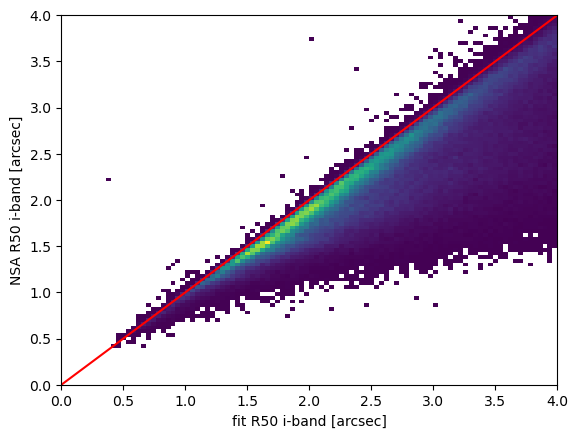

In [16]:
plt.hist2d(nsa['R50_i'], nsa['ELPETRO_TH50'][:,5],
          bins=100,
          range=[[0,4],[0,4]], cmin=1)
# plt.xlim(0,100)
# plt.ylim(0,100)
plt.xlabel('fit R50 i-band [arcsec]')
plt.ylabel('NSA R50 i-band [arcsec]')
plt.plot([0,4],[0,4], color='r')

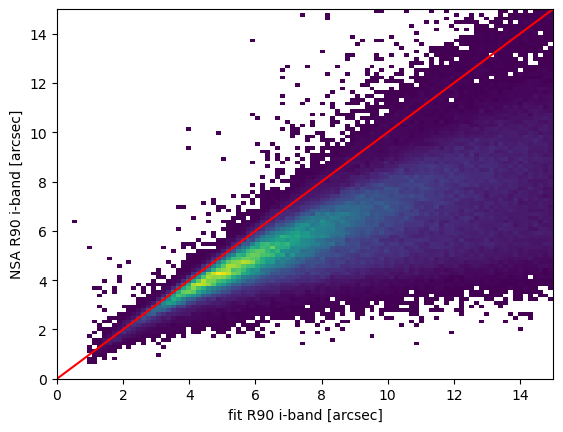

In [17]:
plt.hist2d(nsa['R90_i'], nsa['ELPETRO_TH90'][:,5],
          bins=100,
          range=[[0,15],[0,15]], cmin=1)
# plt.xlim(0,100)
# plt.ylim(0,100)
plt.xlabel('fit R90 i-band [arcsec]')
plt.ylabel('NSA R90 i-band [arcsec]')
plt.plot([0,15],[0,15], color='r')

compare SGA cog to sdss for same galaxy + cut out with circle of size of data
compare data used in sga cog

g-band

## check crossmatched galaxies

In [18]:
SGA_2020_fn = '/global/cfs/cdirs/cosmo/data/sga/2020/SGA-2020.fits'
SGA_2020 = Table.read(SGA_2020_fn, hdu='ELLIPSE')
SGA_2020[:5]

SGA_ID,SGA_GALAXY,GALAXY,PGC,RA_LEDA,DEC_LEDA,MORPHTYPE,PA_LEDA,D25_LEDA,BA_LEDA,Z_LEDA,SB_D25_LEDA,MAG_LEDA,BYHAND,REF,GROUP_ID,GROUP_NAME,GROUP_MULT,GROUP_PRIMARY,GROUP_RA,GROUP_DEC,GROUP_DIAMETER,BRICKNAME,RA,DEC,D26,D26_REF,PA,BA,RA_MOMENT,DEC_MOMENT,SMA_MOMENT,G_SMA50,R_SMA50,Z_SMA50,SMA_SB22,SMA_SB22.5,SMA_SB23,SMA_SB23.5,SMA_SB24,SMA_SB24.5,SMA_SB25,SMA_SB25.5,SMA_SB26,G_MAG_SB22,R_MAG_SB22,Z_MAG_SB22,G_MAG_SB22.5,R_MAG_SB22.5,Z_MAG_SB22.5,G_MAG_SB23,R_MAG_SB23,Z_MAG_SB23,G_MAG_SB23.5,R_MAG_SB23.5,Z_MAG_SB23.5,G_MAG_SB24,R_MAG_SB24,Z_MAG_SB24,G_MAG_SB24.5,R_MAG_SB24.5,Z_MAG_SB24.5,G_MAG_SB25,R_MAG_SB25,Z_MAG_SB25,G_MAG_SB25.5,R_MAG_SB25.5,Z_MAG_SB25.5,G_MAG_SB26,R_MAG_SB26,Z_MAG_SB26,SMA_SB22_ERR,SMA_SB22.5_ERR,SMA_SB23_ERR,SMA_SB23.5_ERR,SMA_SB24_ERR,SMA_SB24.5_ERR,SMA_SB25_ERR,SMA_SB25.5_ERR,SMA_SB26_ERR,G_MAG_SB22_ERR,R_MAG_SB22_ERR,Z_MAG_SB22_ERR,G_MAG_SB22.5_ERR,R_MAG_SB22.5_ERR,Z_MAG_SB22.5_ERR,G_MAG_SB23_ERR,R_MAG_SB23_ERR,Z_MAG_SB23_ERR,G_MAG_SB23.5_ERR,R_MAG_SB23.5_ERR,Z_MAG_SB23.5_ERR,G_MAG_SB24_ERR,R_MAG_SB24_ERR,Z_MAG_SB24_ERR,G_MAG_SB24.5_ERR,R_MAG_SB24.5_ERR,Z_MAG_SB24.5_ERR,G_MAG_SB25_ERR,R_MAG_SB25_ERR,Z_MAG_SB25_ERR,G_MAG_SB25.5_ERR,R_MAG_SB25.5_ERR,Z_MAG_SB25.5_ERR,G_MAG_SB26_ERR,R_MAG_SB26_ERR,Z_MAG_SB26_ERR,G_COG_PARAMS_MTOT,G_COG_PARAMS_M0,G_COG_PARAMS_ALPHA1,G_COG_PARAMS_ALPHA2,G_COG_PARAMS_CHI2,R_COG_PARAMS_MTOT,R_COG_PARAMS_M0,R_COG_PARAMS_ALPHA1,R_COG_PARAMS_ALPHA2,R_COG_PARAMS_CHI2,Z_COG_PARAMS_MTOT,Z_COG_PARAMS_M0,Z_COG_PARAMS_ALPHA1,Z_COG_PARAMS_ALPHA2,Z_COG_PARAMS_CHI2,ELLIPSEBIT
int64,bytes16,bytes29,int64,float64,float64,bytes21,float32,float32,float32,float32,float32,float32,bool,bytes13,int64,bytes35,int16,bool,float64,float64,float32,bytes8,float64,float64,float32,bytes4,float32,float32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int32
2,SGA-2020 2,PGC1283207,1283207,228.3770865,5.4232017,S?,152.2,0.36307806,0.724436,0.03463229,23.40448,16.976,False,LEDA-20181114,0,PGC1283207,1,True,228.3770865,5.4232017,0.36307806,2283p055,228.3770803831908,5.423191398593787,0.49470574,SB26,158.20142,0.545691,228.37700918822188,5.4232652570544015,10.897086,3.3509698,3.1147978,3.240862,5.902337,6.9126143,7.941369,8.997992,10.073601,11.199986,12.391357,13.561038,14.841172,16.966799,16.108246,15.486356,16.879545,16.024958,15.400715,16.818878,15.967034,15.341793,16.776297,15.925804,15.300776,16.746685,15.897334,15.272053,16.725166,15.876816,15.2521105,16.708357,15.862035,15.237181,16.696539,15.851936,15.226998,16.689613,15.844313,15.21976,0.013392451,0.02354,0.021872982,0.01736985,0.024445537,0.039866067,0.05026544,0.08455789,0.122911856,0.005682776,0.0054258136,0.0049038026,0.005588406,0.005323561,0.0047632363,0.00543534,0.005177031,0.0046343105,0.0053025587,0.005040888,0.0045181247,0.005206092,0.0049438984,0.0044374703,0.0051483097,0.0048758644,0.0043834248,0.0051032505,0.0048264163,0.004344248,0.0050705094,0.004792021,0.004319857,0.005054293,0.004765629,0.0043044444,16.65942,0.34037337,0.2978292,3.0239506,0.07928849,15.820566,0.2640441,0.34559453,3.3033552,0.003811298,15.195567,0.29826432,0.3001073,3.2333765,0.011723555,0
3,SGA-2020 3,PGC1310416,1310416,202.54443750000002,6.9345944,Sc,159.26,0.4017908,0.7816278,0.073888786,23.498482,16.85,False,LEDA-20181114,1,PGC1310416,1,True,202.54443750000002,6.9345944,0.4017908,

In [19]:
# crossmatch file
crossmatch_fn = '/pscratch/sd/n/nravi/SGA2020_NSAv101_crossmatch_05182025_0p000215deg.txt'
crossmatch = Table.read(crossmatch_fn, format='ascii.commented_header')

In [20]:
crossmatch[:5]

NSAID,SGA_ID
int64,int64
0,393743
12,1363178
18,833408
19,1348445
24,640610


In [21]:
cross_match_dict = {}
for i in range(len(crossmatch)):

    cross_match_dict[crossmatch['NSAID'][i]] = crossmatch['SGA_ID'][i]

In [22]:
nsa[nsa['cinv'] < 0.01]['NSAID'][0]

240

In [23]:
sga_id = cross_match_dict[240]

In [24]:
sga_dict = {}
for i in range(len(SGA_2020)):
    sga_dict[SGA_2020['SGA_ID'][i]] = i

In [25]:
idx = sga_dict[sga_id]

In [26]:
SGA_2020[idx]

SGA_ID,SGA_GALAXY,GALAXY,PGC,RA_LEDA,DEC_LEDA,MORPHTYPE,PA_LEDA,D25_LEDA,BA_LEDA,Z_LEDA,SB_D25_LEDA,MAG_LEDA,BYHAND,REF,GROUP_ID,GROUP_NAME,GROUP_MULT,GROUP_PRIMARY,GROUP_RA,GROUP_DEC,GROUP_DIAMETER,BRICKNAME,RA,DEC,D26,D26_REF,PA,BA,RA_MOMENT,DEC_MOMENT,SMA_MOMENT,G_SMA50,R_SMA50,Z_SMA50,SMA_SB22,SMA_SB22.5,SMA_SB23,SMA_SB23.5,SMA_SB24,SMA_SB24.5,SMA_SB25,SMA_SB25.5,SMA_SB26,G_MAG_SB22,R_MAG_SB22,Z_MAG_SB22,G_MAG_SB22.5,R_MAG_SB22.5,Z_MAG_SB22.5,G_MAG_SB23,R_MAG_SB23,Z_MAG_SB23,G_MAG_SB23.5,R_MAG_SB23.5,Z_MAG_SB23.5,G_MAG_SB24,R_MAG_SB24,Z_MAG_SB24,G_MAG_SB24.5,R_MAG_SB24.5,Z_MAG_SB24.5,G_MAG_SB25,R_MAG_SB25,Z_MAG_SB25,G_MAG_SB25.5,R_MAG_SB25.5,Z_MAG_SB25.5,G_MAG_SB26,R_MAG_SB26,Z_MAG_SB26,SMA_SB22_ERR,SMA_SB22.5_ERR,SMA_SB23_ERR,SMA_SB23.5_ERR,SMA_SB24_ERR,SMA_SB24.5_ERR,SMA_SB25_ERR,SMA_SB25.5_ERR,SMA_SB26_ERR,G_MAG_SB22_ERR,R_MAG_SB22_ERR,Z_MAG_SB22_ERR,G_MAG_SB22.5_ERR,R_MAG_SB22.5_ERR,Z_MAG_SB22.5_ERR,G_MAG_SB23_ERR,R_MAG_SB23_ERR,Z_MAG_SB23_ERR,G_MAG_SB23.5_ERR,R_MAG_SB23.5_ERR,Z_MAG_SB23.5_ERR,G_MAG_SB24_ERR,R_MAG_SB24_ERR,Z_MAG_SB24_ERR,G_MAG_SB24.5_ERR,R_MAG_SB24.5_ERR,Z_MAG_SB24.5_ERR,G_MAG_SB25_ERR,R_MAG_SB25_ERR,Z_MAG_SB25_ERR,G_MAG_SB25.5_ERR,R_MAG_SB25.5_ERR,Z_MAG_SB25.5_ERR,G_MAG_SB26_ERR,R_MAG_SB26_ERR,Z_MAG_SB26_ERR,G_COG_PARAMS_MTOT,G_COG_PARAMS_M0,G_COG_PARAMS_ALPHA1,G_COG_PARAMS_ALPHA2,G_COG_PARAMS_CHI2,R_COG_PARAMS_MTOT,R_COG_PARAMS_M0,R_COG_PARAMS_ALPHA1,R_COG_PARAMS_ALPHA2,R_COG_PARAMS_CHI2,Z_COG_PARAMS_MTOT,Z_COG_PARAMS_M0,Z_COG_PARAMS_ALPHA1,Z_COG_PARAMS_ALPHA2,Z_COG_PARAMS_CHI2,ELLIPSEBIT
int64,bytes16,bytes29,int64,float64,float64,bytes21,float32,float32,float32,float32,float32,float32,bool,bytes13,int64,bytes35,int16,bool,float64,float64,float32,bytes8,float64,float64,float32,bytes4,float32,float32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,int32
1260274,SGA-2020 1260274,PGC1164276,1164276,145.8265515,0.3731055,S?,38.15,0.41591063,0.4786301,0.021561582,24.718481,17.995,False,LEDA-20181114,463801,PGC1164276,1,True,145.8265515,0.3731055,0.41591063,1458p002,145.82656659333725,0.3731234220814929,0.7947355,SB26,36.894623,0.6103264,145.82634234662007,0.3730883153588436,15.192628,35.86956,33.605347,25.889933,0.6036304,1.9769298,4.3950896,6.7288246,9.434159,12.786384,16.648117,20.565197,23.842064,22.982323,22.255013,21.713442,20.591627,19.855036,19.34608,19.294334,18.56254,18.079306,18.719622,18.006578,17.541008,18.321459,17.620056,17.164808,18.006268,17.314177,16.875755,17.773502,17.094074,16.675705,17.599379,16.934195,16.52039,17.493963,16.835176,16.43473,0.01936455,0.01479198,0.020573622,0.0225171,0.02683214,0.047738742,0.07324064,0.13958709,0.19607297,0.042494353,0.06618337,0.088565335,0.02542451,0.028113062,0.03532247,0.01187387,0.012897829,0.015881158,0.007889856,0.008379027,0.011379824,0.006292267,0.0063217483,0.0090709645,0.0052809007,0.005190414,0.0080069695,0.0046686498,0.0045291823,0.0075408123,0.004275823,0.004190638,0.007229167,0.0041749766,0.004051514,0.007223589,16.493963,2.9630806,0.81213856,0.8085166,2.7253025,15.880382,3.2207725,0.6827614,0.78637123,1.4567788,15.632495,2.884893,0.66710764,0.84694326,1.8081061,0


In [28]:
nsa['SGA_R50_R'] = np.ones(len(nsa))*np.nan

In [29]:
for i in tqdm(range(len(nsa))):

    try:
        sga_id = cross_match_dict[nsa['NSAID'][i]]
    except:
        continue

    sga_idx = sga_dict[sga_id]
    nsa['SGA_R50_R'][i] = SGA_2020['R_SMA50'][sga_idx]

100%|██████████| 641409/641409 [00:01<00:00, 523045.23it/s]


In [30]:
nsa_sga = nsa[nsa['SGA_R50_R'] > 0]

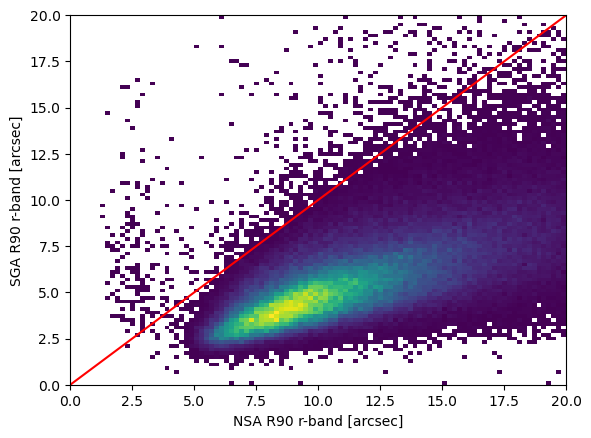

In [31]:
plt.hist2d(nsa['ELPETRO_TH90_R'], nsa['SGA_R50_R'],
          range=[[0,20],[0,20]],
          bins=100, cmin=1)
plt.xlim(0,20)
plt.ylim(0,20)
plt.xlabel('NSA R90 r-band [arcsec]')
plt.ylabel('SGA R90 r-band [arcsec]')
plt.plot([0,20],[0,20], color='r')

(array([0.0000e+00, 1.6000e+01, 1.5400e+02, 7.6000e+02, 1.5200e+03,
        2.3690e+03, 4.0390e+03, 7.6020e+03, 1.3568e+04, 1.9810e+04,
        2.6630e+04, 3.0935e+04, 3.4427e+04, 3.6103e+04, 3.6113e+04,
        3.5351e+04, 3.3536e+04, 3.0826e+04, 2.8432e+04, 2.6065e+04,
        2.3875e+04, 2.1582e+04, 1.9440e+04, 1.7463e+04, 1.5846e+04,
        1.4249e+04, 1.2569e+04, 1.1197e+04, 1.0101e+04, 9.2510e+03,
        8.4330e+03, 7.5390e+03, 6.8950e+03, 6.2320e+03, 5.7200e+03,
        5.2730e+03, 4.8400e+03, 4.5250e+03, 3.9850e+03, 3.6260e+03,
        3.3430e+03, 3.0220e+03, 2.8030e+03, 2.6060e+03, 2.4990e+03,
        2.2750e+03, 2.1690e+03, 1.9780e+03, 1.7690e+03, 1.7640e+03,
        1.6240e+03, 1.4530e+03, 1.4140e+03, 1.2860e+03, 1.2740e+03,
        1.1950e+03, 1.1450e+03, 1.0580e+03, 9.5000e+02, 9.2300e+02,
        8.4800e+02, 7.8300e+02, 8.1000e+02, 7.9100e+02, 7.3900e+02,
        6.9100e+02, 6.3400e+02, 5.9500e+02, 5.7700e+02, 5.5400e+02,
        4.9900e+02, 4.6900e+02, 4.8100e+02, 4.19

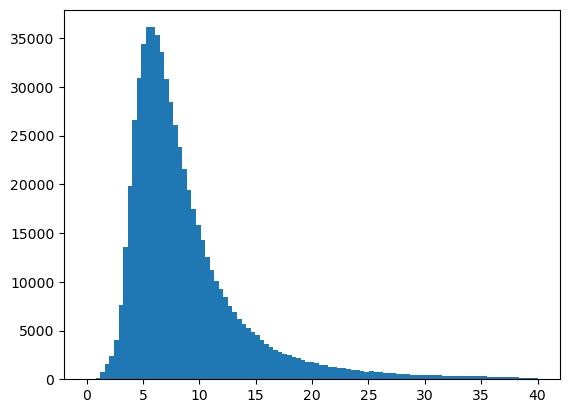

In [35]:
plt.hist(nsa['ELPETRO_TH90_R'], bins=np.linspace(0,40,100))

In [41]:
nsa_sga[25544]

IAUNAME,SUBDIR,RA,DEC,ISDSS,INED,ISIXDF,IALFALFA,IZCAT,ITWODF,MAG,Z,ZSRC,SIZE,RUN,CAMCOL,FIELD,RERUN,XPOS,YPOS,NSAID,ZDIST,SERSIC_NMGY,SERSIC_NMGY_IVAR,SERSIC_OK,SERSIC_RNMGY,SERSIC_ABSMAG,SERSIC_AMIVAR,EXTINCTION,SERSIC_KCORRECT,SERSIC_KCOEFF,SERSIC_MTOL,SERSIC_B300,SERSIC_B1000,SERSIC_METS,SERSIC_MASS,XCEN,YCEN,NPROF,PROFMEAN,PROFMEAN_IVAR,QSTOKES,USTOKES,BASTOKES,PHISTOKES,PETRO_FLUX,PETRO_FLUX_IVAR,FIBER_FLUX,FIBER_FLUX_IVAR,PETRO_BA50,PETRO_PHI50,PETRO_BA90,PETRO_PHI90,SERSIC_FLUX,SERSIC_FLUX_IVAR,SERSIC_N,SERSIC_BA,SERSIC_PHI,ASYMMETRY,CLUMPY,DFLAGS,AID,PID,DVERSION,PROFTHETA,PETRO_THETA,PETRO_TH50,PETRO_TH90,SERSIC_TH50,PLATE,FIBERID,MJD,RACAT,DECCAT,ZSDSSLINE,SURVEY,PROGRAMNAME,PLATEQUALITY,TILE,PLUG_RA,PLUG_DEC,ELPETRO_BA,ELPETRO_PHI,ELPETRO_FLUX_R,ELPETRO_FLUX_IVAR_R,ELPETRO_THETA_R,ELPETRO_TH50_R,ELPETRO_TH90_R,ELPETRO_THETA,ELPETRO_FLUX,ELPETRO_FLUX_IVAR,ELPETRO_TH50,ELPETRO_TH90,ELPETRO_APCORR_R,ELPETRO_APCORR,ELPETRO_APCORR_SELF,ELPETRO_NMGY,ELPETRO_NMGY_IVAR,ELPETRO_OK,ELPETRO_RNMGY,ELPETRO_ABSMAG,ELPETRO_AMIVAR,ELPETRO_KCORRECT,ELPETRO_KCOEFF,ELPETRO_MASS,ELPETRO_MTOL,ELPETRO_B300,ELPETRO_B1000,ELPETRO_METS,IN_DR7_LSS,g_mtot,g_m0,g_a1,g_a2,i_mtot,i_m0,i_a1,i_a2,NSA_cd,R50_i,R90_i,cinv,kias_cinv,SGA_R50_R
bytes19,bytes27,float64,float64,int32,int32,int32,int32,int32,int32,float32,float32,bytes7,float32,int16,uint8,int16,bytes3,float32,float32,int32,float32,float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[7],float32[5],float32[7],float32,float32,float32,float32,float64,float64,uint8[7],"float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]","float32[15,7]",float32[7],float32[7],float32[7],float32[7],float32,float32,float32,float32,float32[7],float32[7],float32,float32,float32,float32[7],float32[7],int32[7],int32,int32,bytes8,float32[15],float32,float32,float32,float32,int32,int16,int32,float64,float64,float32,bytes6,bytes27,bytes8,int32,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32[7],float32[7],float32[7],float32[7],float32,float32[7],float32[7],float32[7],float32[7],int16,float32[7],float32[7],float32[7],float32[7],float32[5],float32,float32[7],float32,float32,float32,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
J142016.40+615937.4,14h/p60/J142016.40+615937.4,215.0597867518644,61.99500282708332,96788,-1,-1,-1,343320,-1,17.941107,0.067489676,sdss,0.06342649,1345,4,453,301,660.42426,647.70245,93682,0.06801657,2.6472623 .. 9740.717,0.15255164 .. 1.35836035e-05,1,4.678627 .. 6969.326,-15.836715 .. -24.229527,0.9069057 .. 1093.3221,0.1654135 .. 0.029511046,0.6236044 .. 0.10193336,0.00065086107 .. 1.7e-44,0.0014318557 .. 0.8437039,4.457904e-10,0.6552705,0.048691332,188975610000.0,236.0,215.0,10 .. 12,0.00089701655 .. 0.0,49.088135 .. 0.0,-14.014613 .. 0.32380155,0.029724399 .. 0.15730156,-0.86679673 .. 0.47060138,89.93924 .. 12.955153,9.500037 .. 4885.406,0.07487472 .. 0.002883885,0.13995229 .. 2608.3215,12.615162 .. 0.008054686,0.79719603,131.55188,0.59752136,122.217285,2.273168 .. 9835.274,0.20719455 .. 0.000832214,2.4486005,0.5802556,118.26123,-2.2104106 .. 0.74363595,-0.9528384 .. 0.41762948,0 .. 0,0,23,v2_1_14,0.22341923 .. 258.39,8.3626795,4.2567143,12.483024,5.774859,606,498,52365,215.0683375176657,61.99373809163466,0.0,sdss,legacy,marginal,407,215.06838,61.993719,0.59752136,122.2173,1294.9292,0.051400654,6.330429,3.4054677,9.332062,6.330429,4.197273 .. 4503.0405,0.18200387 .. 0.0048284526,9.264524 .. 1.8292284,12.207987 .. 6.5929,1.0008711,1.0942572 .. 0.999259,0.98354816 .. 0.99842525,4.8880157 .. 4459.7476,0.13361765 .. 6.498516e-05,1,4.3611956 .. 3856.2397,-16.468933 .. -23.354141,2.7081978 .. 1096.4429,0.589985 .. 0.07474964,0.00025481364 .. 1e-44,103249180000.0,0.0008656468 .. 0.8542228,3.5359604e-10,0.4720145,0.04102732,1.0,14.221430385932598,1.1723180020481776,0.004392690066485058,3.1765720940980313,13.55323523564659,2.88154817068049